In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [85]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               90 non-null     object 
 1   Step                    90 non-null     object 
 2   Input Tokens (Prompt)   90 non-null     int64  
 3   Output Tokens (Answer)  90 non-null     int64  
 4   Total Tokens            90 non-null     int64  
 5   Latency (s)             90 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 4.3+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
count,90.000000,90.000000,90.000000,90.000000
mean,5628.588889,196.900000,5971.677778,2.722333
std,8769.668328,259.154505,8720.184517,2.699779
min,477.000000,3.000000,736.000000,0.590000
25%,754.250000,15.000000,1092.250000,0.852500
50%,1125.500000,67.500000,1623.500000,1.205000
75%,9402.500000,317.000000,9407.500000,4.330000
max,27481.000000,1164.000000,27585.000000,13.940000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79


In [86]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens',
    'Latency (s)': 'Latency'
})

df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if '_Naive' in x else 'FRB' if '_FRB' in x else 'HRB')

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens,Latency,Extra Tokens,Model
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28,0,HRB
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67,775,HRB
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82,0,HRB
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33,192,FRB
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79,0,FRB


In [87]:
step_token_usage_df = df.groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].mean().reset_index() 
display(step_token_usage_df)
step_time_usage_df = df.groupby(['Step', 'Model'])['Latency'].mean().reset_index()
display(step_time_usage_df)

model_token_usage_df = step_token_usage_df.groupby('Model')[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].sum().reset_index()
display(model_token_usage_df)
model_time_usage_df = step_time_usage_df.groupby('Model')['Latency'].sum().reset_index()
display(model_time_usage_df)

,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,Evaluator_FRB,FRB,1291.615385,56.538462,0.000000,1348.153846
1,Evaluator_HRB,HRB,1203.153846,58.615385,0.000000,1261.769231
2,Evaluator_Naive,Naive,26744.000000,55.166667,0.333333,26799.500000
3,Generator_FRB,FRB,863.692308,563.615385,499.923077,1927.230769
4,Generator_HRB,HRB,929.615385,468.384615,425.307692,1823.307692
5,Generator_Naive,Naive,26376.500000,368.666667,181.500000,26926.666667
6,Router_FRB,FRB,746.076923,12.000000,1.538462,759.615385
7,Router_HRB,HRB,9415.846154,8.384615,1.384615,9425.615385


,Step,Model,Latency
0,Evaluator_FRB,FRB,0.961538
1,Evaluator_HRB,HRB,0.950000
2,Evaluator_Naive,Naive,1.525000
3,Generator_FRB,FRB,6.205385
4,Generator_HRB,HRB,6.026923
5,Generator_Naive,Naive,4.751667
6,Router_FRB,FRB,0.791538
7,Router_HRB,HRB,1.014615


,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,FRB,2901.384615,632.153846,501.461538,4035.000000
1,HRB,11548.615385,535.384615,426.692308,12510.692308
2,Naive,53120.500000,423.833333,181.833333,53726.166667


,Model,Latency
0,FRB,7.958462
1,HRB,7.991538
2,Naive,6.276667


## Plots

### Cmap

In [88]:
# Colormap for each Step category

FRB = "#1F77B4"
HRB = "#328F3A"
full_db = "#f93e3e"

step_cmap = {
    'Router_FRB': FRB,
    'Generator_FRB': FRB,
    'Evaluator_FRB': FRB,

    'Router_HRB': HRB,
    'Generator_HRB': HRB,
    'Evaluator_HRB': HRB,

    'Generator_Naive': full_db,
    'Evaluator_Naive': full_db
}

model_cmap = {
    'FRB': FRB,
    'HRB': HRB,
    'Naive': full_db
}

### Comparison

#### Average token per model

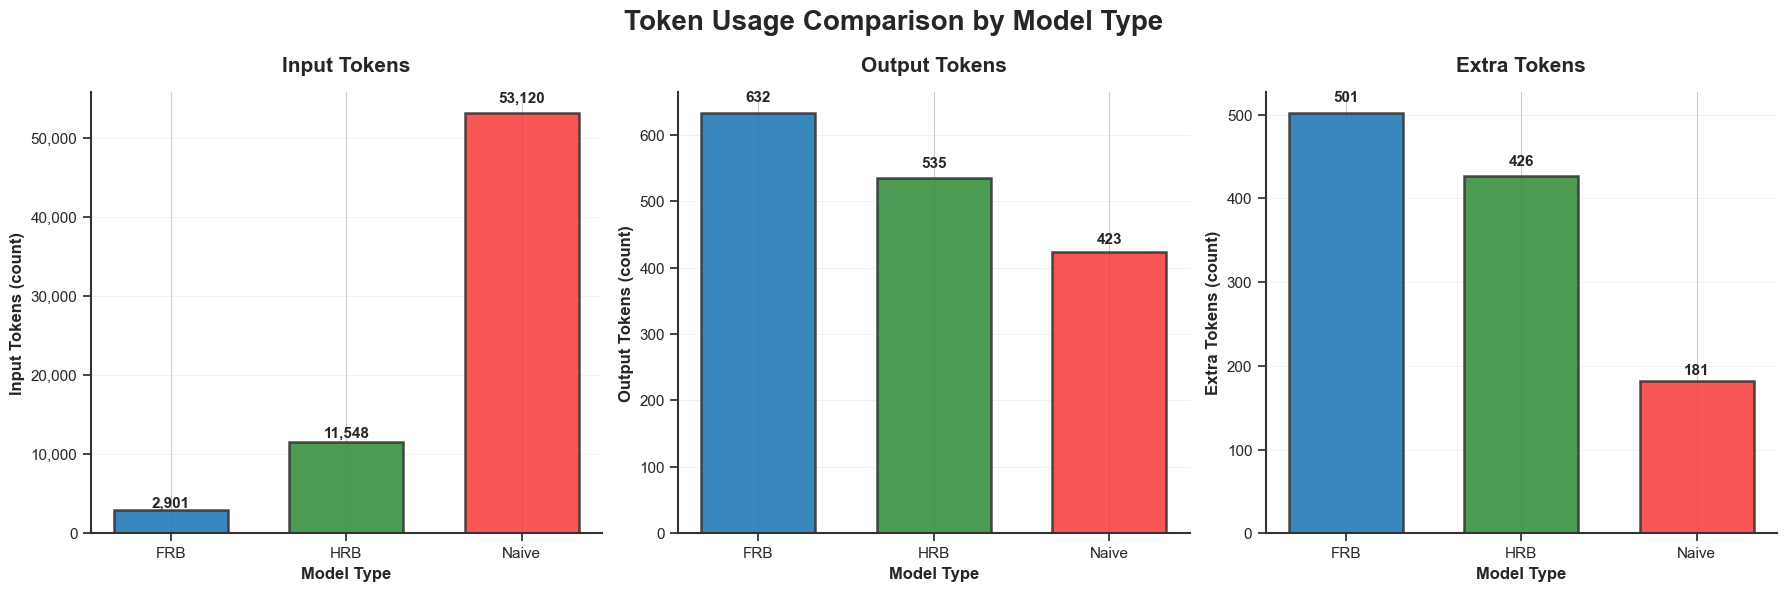

In [89]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    
    bars = ax.bar(model_token_usage_df['Model'], model_token_usage_df[metric], 
                   color=[model_cmap[model] for model in model_token_usage_df['Model']],
                   edgecolor='#333333', linewidth=1.8, alpha=0.88, width=0.65)
    
    ax.set_title(f'{metric}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel(f'{metric} (count)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Improve tick labels
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)
    ax.tick_params(axis='y', which='minor', labelsize=10)
    
    # Format y-axis with thousand separators
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Add value labels on bars with better formatting
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.02,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

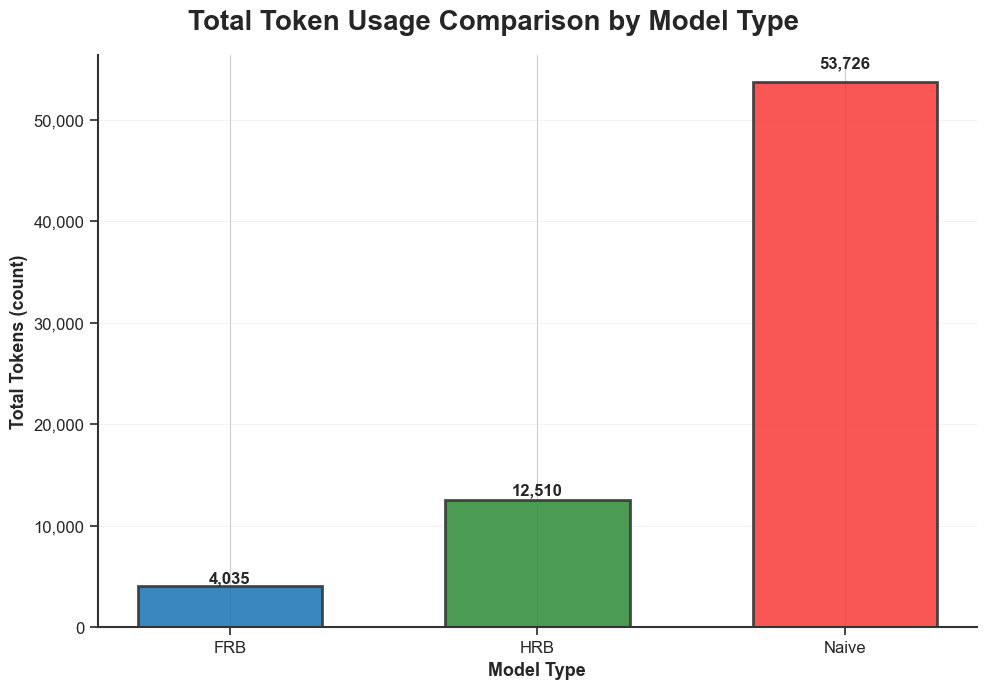

In [90]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_token_usage_df['Model'],
    model_token_usage_df['Total Tokens'],
    color=[model_cmap[model] for model in model_token_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Tokens (count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

# Format y-axis with thousand separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        #family='serif'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

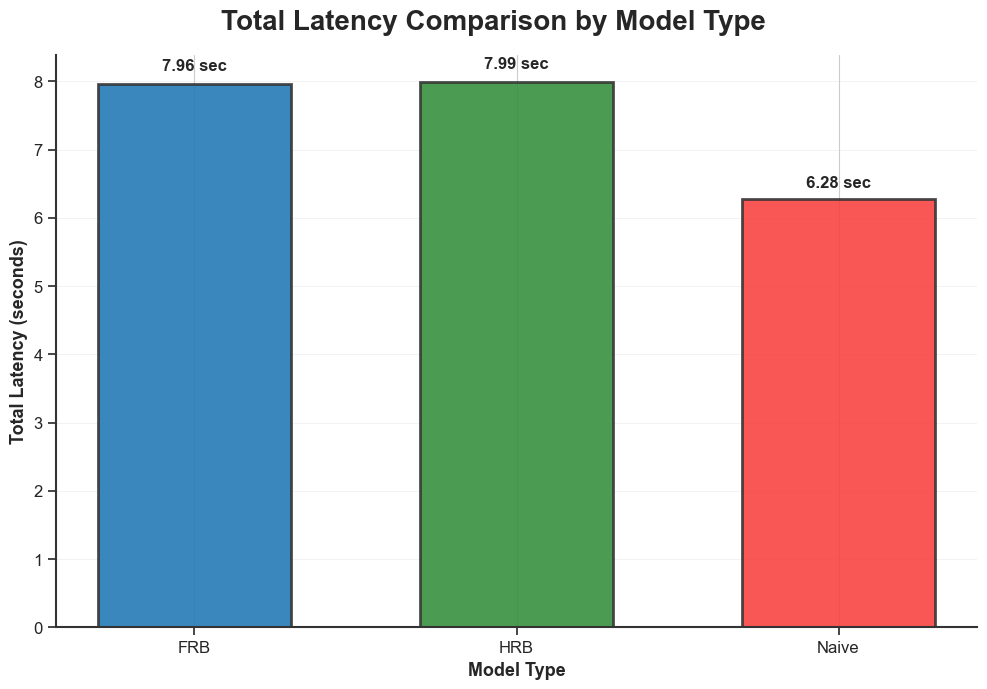

In [91]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Latency Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_time_usage_df['Model'],
    model_time_usage_df['Latency'],
    color=[model_cmap[model] for model in model_time_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Latency (seconds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{height:.2f} sec',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

In [94]:
print(df['Step'].value_counts())
print('\n\n')
print(df['Model'].value_counts())

Step
Router_HRB         13
Generator_HRB      13
Evaluator_HRB      13
Generator_FRB      13
Evaluator_FRB      13
Router_FRB         13
Generator_Naive     6
Evaluator_Naive     6
Name: count, dtype: int64



Model
HRB      39
FRB      39
Naive    12
Name: count, dtype: int64
